# ML

### Overall Strategy
We have 3 models: (1) AdaBoost, (2) Gradient Boost, and (3) Random Forest. We use a mix of Grid and Random Search for optimal parameteres and pair this with a 60-20-20 split for each model specification. 

Using the variety of parameters, we construct a normal approximation and evaluate whether or not the best model is statistically different from the average model. We will then compare the models using McNemar's pairwise test and finally conduct some performance metrics on the best model.

### Preliminaries

##### Packages

In [41]:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn

import pandas as pd
import numpy as np
import random, time
from itertools import product
from operator import itemgetter
import matplotlib.pyplot as plt
from scipy.stats import norm

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier

random.seed(123)

##### Printing Objects

In [42]:
def stringify(res): # Takes in a result object of { 'score': int, ['options': values] }
    iterated_keys = list(set(res.keys()) - set(['score']))
    specs_string = f'({', '.join([str(res[x]) for x in iterated_keys])})'
    return f'{specs_string}; score: {round(res['score'], 3)}'

### Dataset

In [43]:
df = pd.read_csv('hie_dataset.csv')
df

,country,year,"GNI per capita, Atlas method (current US$)","Population, total",Surface area (sq. km),Population living in slums (% of urban population),hie,near_2_plus_oceans,border_count,size
0,Albania,2000,1130.0,3089027.0,28750.0,28.10000,False,False,4.0,small
1,Angola,2000,360.0,16194869.0,1246700.0,19.70000,False,False,4.0,large
2,Argentina,2000,7400.0,37213984.0,2780400.0,20.29188,False,True,5.0,large
3,Armenia,2000,630.0,3221100.0,29740.0,12.79599,False,False,4.0,small
4,Aruba,2000,20060.0,90588.0,180.0,0.00000,True,False,0.0,small
...,...,...,...,...,...,...,...,...,...,...
1897,Vanuatu,2022,3830.0,313046.0,12190.0,3.06400,False,False,0.0,small
1898,Venezuela,2022,2260.0,28213017.0,912050.0,25.70000,False,False,3.0,medium
1899,Vietnam,2022,3980.0,99680655.0,331340.0,32.50000,False,False,3.0,large
1900,Zambia,2022,1170.0,20152938.0,752610.0,48.25813,False,False,8.0,medium


### Data
60, 20, 20 split

In [44]:
x_overall = df[['year', "Population living in slums (% of urban population)", 'near_2_plus_oceans', 'border_count', 'size']]
y = df[['hie']]
one_hot = pd.get_dummies(x_overall['size'])
x_overall = x_overall.drop('size', axis = 1)
x_overall = x_overall.join(one_hot)
X_train, X_test_val, y_train, y_test_val = train_test_split(x_overall, y, test_size = 0.4, random_state = 123)
X_test, X_valid, y_test, y_valid = train_test_split(X_test_val, y_test_val, test_size = 0.5, random_state = 123)

### AdaBoosting

Training: (gini, 1, 1.0982345927989308); score: 0.929
Training: (gini, 1, 0.8930696674751897); score: 0.921
Training: (gini, 1, 0.8634257267821015); score: 0.924
Training: (gini, 1, 1.0256573845414456); score: 0.929
Training: (gini, 1, 1.1097344848927815); score: 0.932
Training: (gini, 1, 0.9615532300622305); score: 0.927
Training: (gini, 1, 1.2403820991923078); score: 0.927
Training: (gini, 1, 1.0924148692924316); score: 0.932
Training: (gini, 3, 1.0982345927989308); score: 0.934
Training: (gini, 3, 0.8930696674751897); score: 0.929
Training: (gini, 3, 0.8634257267821015); score: 0.932
Training: (gini, 3, 1.0256573845414456); score: 0.921
Training: (gini, 3, 1.1097344848927815); score: 0.937
Training: (gini, 3, 0.9615532300622305); score: 0.927
Training: (gini, 3, 1.2403820991923078); score: 0.932
Training: (gini, 3, 1.0924148692924316); score: 0.945
Training: (gini, 5, 1.0982345927989308); score: 0.932
Training: (gini, 5, 0.8930696674751897); score: 0.942
Training: (gini, 5, 0.863425

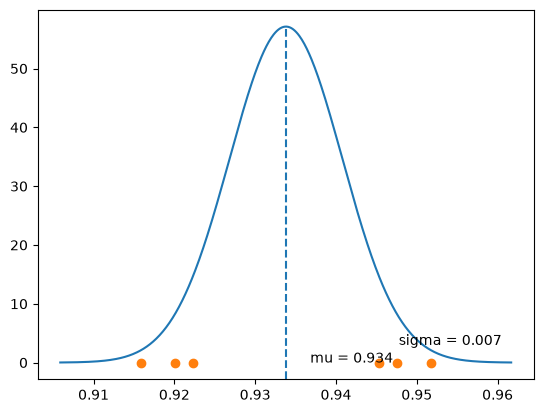

Standard Distance = 2.748477470972772, p-value = 0.00299363746769348


In [46]:
np.random.seed(123)
options = { 'criterion': ['gini', 'entropy'], 'max-depth': [1, 3, 5, 7], 'learning-rate': np.random.rand(8) * 0.5 + 0.75 }
keys, values = zip(*options.items())
option_combos = [dict(zip(keys, p)) for p in product(*values)]

results = []
for combo in option_combos:
    # Training
    estimator = DecisionTreeClassifier(criterion = combo['criterion'], max_depth = combo['max-depth'], random_state = 123)
    clf = AdaBoostClassifier(estimator = estimator, n_estimators = 100, random_state = 0, learning_rate = combo['learning-rate'])
    clf.fit(X_train, y_train.values.ravel())
    
    # Cross Validation (Holdout)
    score = clf.score(X_valid, y_valid)
    res = { 'score': score, 'criterion': combo['criterion'], 'max-depth': combo['max-depth'], 'learning-rate': combo['learning-rate'] }
    results.append(res)
    print(f'Training: {stringify(res)}')

sorted_results = sorted(results, key = lambda d: d['score'], reverse = True)
print(f'Best Valid.: {stringify(sorted_results[0])}')

# Training the Final Model and Testing
final_estimator = DecisionTreeClassifier(criterion = sorted_results[0]['criterion'], max_depth = sorted_results[0]['max-depth'], random_state = 123)
final_clf = AdaBoostClassifier(estimator = estimator, n_estimators = 100, random_state = 0, learning_rate = sorted_results[0]['learning-rate'])
final_clf.fit(pd.concat([X_train, X_valid]), pd.concat([y_train, y_valid]).values.ravel())
final_score = final_clf.score(X_test, y_test) # type: ignore
final_res = { 'score': round(final_score, 3), 'criterion': sorted_results[0]['criterion'], 'max-depth': sorted_results[0]['max-depth'], 'learning-rate': sorted_results[0]['learning-rate'] }
print(f'Final: {stringify(final_res)}')

scores = np.array([d['score'] for d in results])
gen_CI(scores.mean(), scores.std())

stds_away = (final_res['score'] - scores.mean()) / scores.std()
p_value = norm.sf(abs(stds_away)) # a one-sided stat was used because we know that this value will be above the mean.

print(f'Standard Distance = {stds_away}, p-value = {p_value}')

### Gradient Boosting

Training: (log_loss, 1, 0.15447037783967926); score: 0.927
Training: (log_loss, 3, 0.15447037783967926); score: 0.924
Training: (log_loss, 5, 0.15447037783967926); score: 0.934
Training: (log_loss, 7, 0.15447037783967926); score: 0.94
Training: (log_loss, 1, 0.09292090024255692); score: 0.919
Training: (log_loss, 3, 0.09292090024255692); score: 0.937
Training: (log_loss, 5, 0.09292090024255692); score: 0.932
Training: (log_loss, 7, 0.09292090024255692); score: 0.94
Training: (log_loss, 1, 0.08402771803463047); score: 0.919
Training: (log_loss, 3, 0.08402771803463047); score: 0.942
Training: (log_loss, 5, 0.08402771803463047); score: 0.934
Training: (log_loss, 7, 0.08402771803463047); score: 0.942
Training: (log_loss, 1, 0.13269721536243367); score: 0.927
Training: (log_loss, 3, 0.13269721536243367); score: 0.94
Training: (log_loss, 5, 0.13269721536243367); score: 0.927
Training: (log_loss, 7, 0.13269721536243367); score: 0.94
Training: (log_loss, 1, 0.15792034546783446); score: 0.927
T

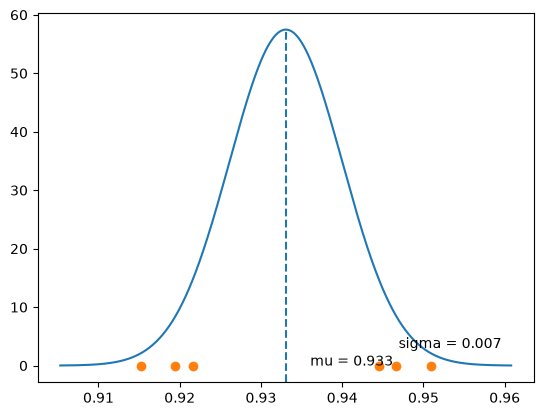

Standard Distance = 2.8722425136388585, p-value = 0.002037850315901044


In [48]:
np.random.seed(123)
options = { 'loss': ['log_loss', 'exponential'], 'learning-rate': np.random.rand(8) * 0.15 + 0.05, 'max-depth': [1, 3, 5, 7] }
keys, values = zip(*options.items())
option_combos = [dict(zip(keys, p)) for p in product(*values)]

results = []
for combo in option_combos:
    # Training
    clf = GradientBoostingClassifier(loss = combo['loss'], learning_rate = combo['learning-rate'], max_depth = combo['max-depth'], random_state = 123)
    clf.fit(X_train, y_train.values.ravel())
    
    # Cross Validation (Holdout)
    score = clf.score(X_valid, y_valid)
    res = { 'score': round(score, 3), 'loss': combo['loss'], 'max-depth': combo['max-depth'], 'learning-rate': combo['learning-rate'] }
    results.append(res)
    print(f'Training: {stringify(res)}')


sorted_results = sorted(results, key = lambda d: d['score'], reverse = True)
print(f'Best Valid.: {stringify(sorted_results[0])}')

# Training the Final Model and Testing
final_clf = GradientBoostingClassifier(loss = sorted_results[0]['loss'], learning_rate = sorted_results[0]['learning-rate'], max_depth = sorted_results[0]['max-depth'], random_state = 123)
final_clf.fit(pd.concat([X_train, X_valid]), pd.concat([y_train, y_valid]).values.ravel())
final_score = final_clf.score(X_test, y_test) # type: ignore
final_res = { 'score': round(final_score, 3), 'loss': sorted_results[0]['loss'], 'max-depth': sorted_results[0]['max-depth'], 'learning-rate': sorted_results[0]['learning-rate'] }
print(f'Final: {stringify(final_res)}')

scores = np.array([d['score'] for d in results])
gen_CI(scores.mean(), scores.std())

stds_away = (final_res['score'] - scores.mean()) / scores.std()
p_value = norm.sf(abs(stds_away)) # a one-sided stat was used because we know that this value will be above the mean.

print(f'Standard Distance = {stds_away}, p-value = {p_value}')

### Random Forest

(gini, 2, sqrt); score: 0.916
(gini, 2, log2); score: 0.916
(gini, 2, None); score: 0.919
(gini, 4, sqrt); score: 0.919
(gini, 4, log2); score: 0.919
(gini, 4, None); score: 0.921
(gini, 6, sqrt); score: 0.924
(gini, 6, log2); score: 0.924
(gini, 6, None); score: 0.94
(gini, 8, sqrt); score: 0.932
(gini, 8, log2); score: 0.932
(gini, 8, None); score: 0.934
(entropy, 2, sqrt); score: 0.919
(entropy, 2, log2); score: 0.919
(entropy, 2, None); score: 0.919
(entropy, 4, sqrt); score: 0.919
(entropy, 4, log2); score: 0.919
(entropy, 4, None); score: 0.919
(entropy, 6, sqrt); score: 0.924
(entropy, 6, log2); score: 0.924
(entropy, 6, None); score: 0.932
(entropy, 8, sqrt); score: 0.927
(entropy, 8, log2); score: 0.927
(entropy, 8, None); score: 0.932
(log_loss, 2, sqrt); score: 0.919
(log_loss, 2, log2); score: 0.919
(log_loss, 2, None); score: 0.919
(log_loss, 4, sqrt); score: 0.919
(log_loss, 4, log2); score: 0.919
(log_loss, 4, None); score: 0.919
(log_loss, 6, sqrt); score: 0.924
(log_lo

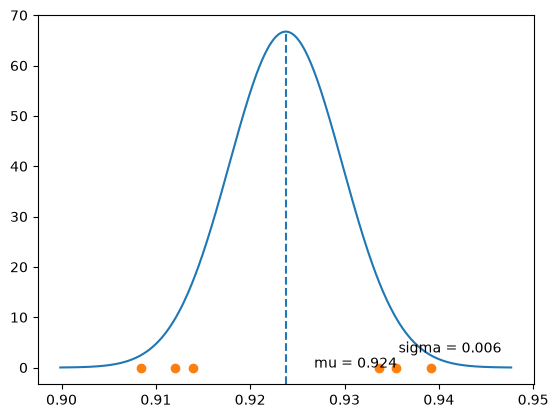

Standard Distance = 2.21206405128016, p-value = 0.01348111979105276


In [49]:
options = { 'criterion': ['gini', 'entropy', 'log_loss'], 'max-depth': [2, 4, 6, 8], 'max-features': ['sqrt', 'log2', None] }
keys, values = zip(*options.items())
option_combos = [dict(zip(keys, p)) for p in product(*values)]

results = []
for combo in option_combos:
    # Training
    clf = RandomForestClassifier(criterion = combo['criterion'], max_depth = combo['max-depth'], max_features = combo['max-features'], random_state = 123)
    clf.fit(X_train, y_train.values.ravel())
    
    # Cross Validation (Holdout)
    score = clf.score(X_valid, y_valid)
    res = { 'score': round(score, 3), 'criterion': combo['criterion'], 'max-depth': combo['max-depth'], 'max-features': combo['max-features'] }
    results.append(res)
    print(stringify(res))

sorted_results = sorted(results, key = lambda d: d['score'], reverse = True)
print(f'Best Valid.: {stringify(sorted_results[0])}')

# Training the Final Model and Testing
final_clf = RandomForestClassifier(criterion = sorted_results[0]['criterion'], max_depth = sorted_results[0]['max-depth'], max_features = sorted_results[0]['max-features'], random_state = 123)
final_clf.fit(pd.concat([X_train, X_valid]), pd.concat([y_train, y_valid]).values.ravel())
final_score = final_clf.score(X_test, y_test) # type: ignore
final_res = { 'score': round(final_score, 3), 'criterion': sorted_results[0]['criterion'], 'max-depth': sorted_results[0]['max-depth'], 'max_features': sorted_results[0]['max-features'] }
print(f'Final: {stringify(final_res)}')

scores = np.array([d['score'] for d in results])
gen_CI(scores.mean(), scores.std())

stds_away = (final_res['score'] - scores.mean()) / scores.std()
p_value = norm.sf(abs(stds_away)) # a one-sided stat was used because we know that this value will be above the mean.

print(f'Standard Distance = {stds_away}, p-value = {p_value}')

Summary of the above for further testing and model evaluation.

### Now Testing Cross Validation
##### Generating Confidence Interval Graph

In [ ]:
def gen_CI(mean, std):
    ax = np.arange(mean - 4 * std, mean + 4 * std, 0.0001)
    plt.plot(ax, norm.pdf(ax, mean, std))
    plt.axvline(mean, 0, 0.95, linestyle = 'dashed')
    # plt.axhline(1, mean - 2 * std, mean - std)
    plt.text(mean + 0.003, 0, f'mu = {round(mean, 3)}', rotation = 0)
    plt.text(mean + 2 * std, 3, f'sigma = {round(std, 3)}', rotation = 0)

    x_CIs = []
    for alpha in [0.9, 0.95, 0.99]:
        x_CIs.extend(norm.interval(alpha, loc = mean, scale = std))
    x_CIs = np.array(x_CIs)
    y_points = np.array([0] * 6)
    plt.plot(x_CIs, y_points, 'o')
    plt.show()

##### Testing the CV with the Holdout-Optimal Random Forest

Mean: 0.939, Std: 0.023


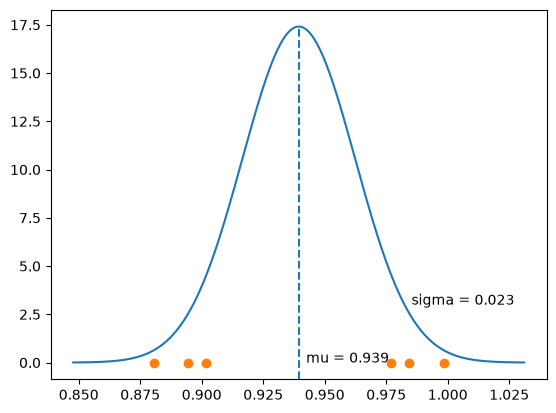

In [ ]:
clf = RandomForestClassifier(criterion = 'gini', max_depth = 6, max_features = None, random_state = 123)
scores = cross_val_score(clf, x_overall, y, cv = 30) # For CLT Normality
print(f'Mean: {round(scores.mean(), 3)}, Std: {round(scores.std(), 3)}')

gen_CI(scores.mean(), scores.std())